In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
model_df=pd.read_csv('hourlyLoadData_NE_weather_with_holiday.csv')


In [ ]:
print(model_df.head())
#%%


        datetime  North-Eastern Region Hourly Demand  temp_ne  humidity_ne  \
0  1/1/2019 0:00                             1665.72     11.4           91   
1  1/1/2019 1:00                             1556.24     10.4           92   
2  1/1/2019 2:00                             1485.44      9.6           93   
3  1/1/2019 3:00                             1454.96      9.1           91   
4  1/1/2019 4:00                             1463.14      8.9           88   

   feels_like_ne  is_holiday  
0           10.7           1  
1            9.6           1  
2            8.5           1  
3            7.7           1  
4            7.5           1  


In [ ]:
model_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46728 entries, 0 to 46727
Data columns (total 6 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   datetime                            46728 non-null  object 
 1   North-Eastern Region Hourly Demand  46728 non-null  float64
 2   temp_ne                             46728 non-null  float64
 3   humidity_ne                         46728 non-null  int64  
 4   feels_like_ne                       46728 non-null  float64
 5   is_holiday                          46728 non-null  int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 2.1+ MB


In [ ]:
model_df.describe()


,North-Eastern Region Hourly Demand,temp_ne,humidity_ne,feels_like_ne,is_holiday
count,46728.00000,46728.000000,46728.000000,46728.000000,46728.000000
mean,2007.36047,23.520611,79.603642,26.709123,0.045198
std,436.58010,5.206864,15.549451,7.344566,0.207740
min,567.00000,7.900000,16.000000,6.400000,0.000000
25%,1689.17750,20.000000,70.000000,21.000000,0.000000
50%,1968.65000,24.500000,84.000000,27.800000,0.000000
75%,2290.20250,27.200000,92.000000,32.600000,0.000000
max,3586.43000,38.800000,100.000000,44.800000,1.000000


<Axes: >

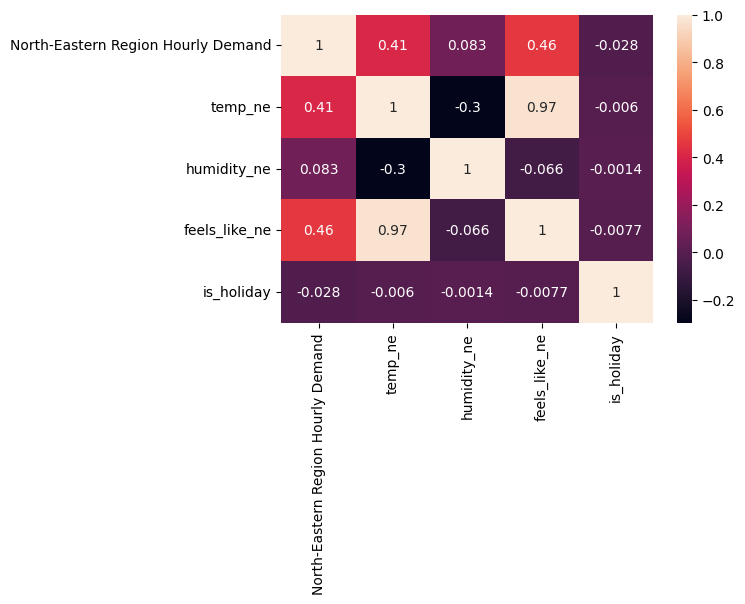

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(model_df.corr(numeric_only=True),annot=True)

In [ ]:
print(model_df.dtypes)
print(model_df['datetime'].head(5))

datetime                               object
North-Eastern Region Hourly Demand    float64
temp_ne                               float64
humidity_ne                             int64
feels_like_ne                         float64
is_holiday                              int64
dtype: object
0    1/1/2019 0:00
1    1/1/2019 1:00
2    1/1/2019 2:00
3    1/1/2019 3:00
4    1/1/2019 4:00
Name: datetime, dtype: object


In [ ]:
model_df['datetime']=pd.to_datetime(model_df['datetime'])
print(model_df['datetime'].dtype)
print(model_df['datetime'].head(3))

datetime64[ns]
0   2019-01-01 00:00:00
1   2019-01-01 01:00:00
2   2019-01-01 02:00:00
Name: datetime, dtype: datetime64[ns]


In [ ]:
model_df['hour']=model_df['datetime'].dt.hour
model_df['day_of_week']=model_df['datetime'].dt.dayofweek
model_df['day_of_month']=model_df['datetime'].dt.day
model_df['month']=model_df['datetime'].dt.month
model_df['quarter']=model_df['datetime'].dt.quarter
model_df['year']=model_df['datetime'].dt.year
model_df['is_weekend']=(model_df['datetime'].dt.dayofweek >= 5).astype(int)
print(model_df[['datetime','hour','day_of_week','month','year','is_weekend']].head(5))

             datetime  hour  day_of_week  month  year  is_weekend
0 2019-01-01 00:00:00     0            1      1  2019           0
1 2019-01-01 01:00:00     1            1      1  2019           0
2 2019-01-01 02:00:00     2            1      1  2019           0
3 2019-01-01 03:00:00     3            1      1  2019           0
4 2019-01-01 04:00:00     4            1      1  2019           0


In [ ]:
model_df['hour_sin']=np.sin(2*np.pi*model_df['hour']/24)
model_df['hour_cos']=np.cos(2*np.pi*model_df['hour']/24)

model_df['dow_sin']=np.sin(2*np.pi*model_df['day_of_week']/7)
model_df['dow_cos']=np.cos(2*np.pi*model_df['day_of_week']/7)

model_df['month_sin']=np.sin(2*np.pi*model_df['month']/12)
model_df['month_cos']=np.cos(2*np.pi*model_df['month']/12)

print(model_df[['hour','hour_sin','hour_cos','day_of_week','dow_sin','dow_cos']].head(5))

   hour  hour_sin  hour_cos  day_of_week   dow_sin  dow_cos
0     0  0.000000  1.000000            1  0.781831  0.62349
1     1  0.258819  0.965926            1  0.781831  0.62349
2     2  0.500000  0.866025            1  0.781831  0.62349
3     3  0.707107  0.707107            1  0.781831  0.62349
4     4  0.866025  0.500000            1  0.781831  0.62349


In [ ]:
TARGET='North-Eastern Region Hourly Demand'
model_df['lag_1h']=model_df[TARGET].shift(1)
model_df['lag_24h']=model_df[TARGET].shift(24)
model_df['lag_48h']=model_df[TARGET].shift(48)
model_df['lag_168h']=model_df[TARGET].shift(168)
model_df['lag_336h']=model_df[TARGET].shift(336)
model_df['rolling_mean_24h']=model_df[TARGET].shift(1).rolling(24).mean()
model_df['rolling_mean_168h']=model_df[TARGET].shift(1).rolling(168).mean()
model_df['rolling_std_24h']=model_df[TARGET].shift(1).rolling(24).std()
model_df['rolling_max_24h']=model_df[TARGET].shift(1).rolling(24).max()
model_df['rolling_min_24h']=model_df[TARGET].shift(1).rolling(24).min()

model_df.head(5)

,datetime,North-Eastern Region Hourly Demand,temp_ne,humidity_ne,feels_like_ne,is_holiday,hour,day_of_week,day_of_month,month,...,lag_1h,lag_24h,lag_48h,lag_168h,lag_336h,rolling_mean_24h,rolling_mean_168h,rolling_std_24h,rolling_max_24h,rolling_min_24h
0,2019-01-01 00:00:00,1665.72,11.4,91,10.7,1,0,1,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2019-01-01 01:00:00,1556.24,10.4,92,9.6,1,1,1,1,1,...,1665.72,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-01-01 02:00:00,1485.44,9.6,93,8.5,1,2,1,1,1,...,1556.24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-01-01 03:00:00,1454.96,9.1,91,7.7,1,3,1,1,1,...,1485.44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-01-01 04:00:00,1463.14,8.9,88,7.5,1,4,1,1,1,...,1454.96,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(model_df.shape)
model_df.dropna(inplace=True)
model_df.reset_index(drop=True, inplace=True)
print(model_df.shape)

(46728, 29)
(46392, 29)


In [ ]:
feature_cols=[col for col in model_df.columns
                if col not in ['datetime', TARGET]]

print(f"Total features:{len(feature_cols)}")
print("\nFeature list:")
for i,col in enumerate(feature_cols, 1):
    print(f"{i:2d}.{col}")

Total features:27

Feature list:
 1.temp_ne
 2.humidity_ne
 3.feels_like_ne
 4.is_holiday
 5.hour
 6.day_of_week
 7.day_of_month
 8.month
 9.quarter
10.year
11.is_weekend
12.hour_sin
13.hour_cos
14.dow_sin
15.dow_cos
16.month_sin
17.month_cos
18.lag_1h
19.lag_24h
20.lag_48h
21.lag_168h
22.lag_336h
23.rolling_mean_24h
24.rolling_mean_168h
25.rolling_std_24h
26.rolling_max_24h
27.rolling_min_24h


In [ ]:
print(model_df.head())
#%%


             datetime  North-Eastern Region Hourly Demand  temp_ne  \
0 2019-01-15 00:00:00                             1502.11     14.0   
1 2019-01-15 01:00:00                             1404.18     13.7   
2 2019-01-15 02:00:00                             1366.26     13.2   
3 2019-01-15 03:00:00                             1353.51     13.0   
4 2019-01-15 04:00:00                             1363.48     12.8   

   humidity_ne  feels_like_ne  is_holiday  hour  day_of_week  day_of_month  \
0           81           13.1           1     0            1            15   
1           79           12.8           1     1            1            15   
2           78           12.2           1     2            1            15   
3           78           11.6           1     3            1            15   
4           77           11.4           1     4            1            15   

   month  ...   lag_1h  lag_24h  lag_48h  lag_168h  lag_336h  \
0      1  ...  1666.11  1425.06  1471.21   148

In [ ]:
model_df.isnull().sum()


,0
datetime,0
North-Eastern Region Hourly Demand,0
temp_ne,0
humidity_ne,0
feels_like_ne,0
is_holiday,0
hour,0
day_of_week,0
day_of_month,0
month,0


In [ ]:
EXCLUDE=['datetime','North-Eastern Region Hourly Demand']
FEATURE_COLS=[col for col in model_df.columns if col not in EXCLUDE]
TARGET='North-Eastern Region Hourly Demand'

In [ ]:
SPLIT_DATE='2023-01-01'
train=model_df[model_df['datetime']<SPLIT_DATE].copy()
test=model_df[model_df['datetime']>=SPLIT_DATE].copy()
X_train=train[FEATURE_COLS]
y_train=train[TARGET]
X_test=test[FEATURE_COLS]
y_test=test[TARGET]
print(f"X_train shape:{X_train.shape}")
print(f"X_test shape:{X_test.shape}")

X_train shape:(34728, 27)
X_test shape:(11664, 27)


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from scipy.stats import uniform, loguniform, randint
import lightgbm as lgb
import time

param_dist = {
    'n_estimators': randint(300, 2000),
    'learning_rate': loguniform(0.005, 0.2),
    'max_depth': randint(4, 12),
    'num_leaves': randint(15, 255),
    'min_child_samples': randint(5, 100),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'reg_alpha': loguniform(1e-3, 10),
    'reg_lambda': loguniform(1e-3, 10),
}

base_model = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)
tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=50,
    scoring='neg_mean_absolute_error',
    cv=tscv,
    verbose=2,
    n_jobs=1,
    random_state=42
)

start = time.time()
random_search.fit(X_train, y_train)
elapsed = time.time() - start

print(f"Time taken: {elapsed/60:.1f} minutes")
print(f"Best CV MAE: {-random_search.best_score_:.2f} MW")
print(f"Best params: {random_search.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.1667521176194013, max_depth=6, min_child_samples=76, n_estimators=1344, num_leaves=117, reg_alpha=0.06071989493441298, reg_lambda=0.002511306167739001, subsample=0.7296244459829335; total time=   1.8s
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.1667521176194013, max_depth=6, min_child_samples=76, n_estimators=1344, num_leaves=117, reg_alpha=0.06071989493441298, reg_lambda=0.002511306167739001, subsample=0.7296244459829335; total time=   4.6s
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.1667521176194013, max_depth=6, min_child_samples=76, n_estimators=1344, num_leaves=117, reg_alpha=0.06071989493441298, reg_lambda=0.002511306167739001, subsample=0.7296244459829335; total time=   3.3s
[CV] END colsample_bytree=0.6872700594236812, learning_rate=0.1667521176194013, max_depth=6, min_child_samples=76, n_estimators=1344, num_leaves=117,

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

rs_model = random_search.best_estimator_
y_pred_rs = rs_model.predict(X_test)

mae_rs = mean_absolute_error(y_test, y_pred_rs)
rmse_rs = np.sqrt(mean_squared_error(y_test, y_pred_rs))
mape_rs = np.mean(np.abs((y_test - y_pred_rs) / y_test)) * 100
r2_rs = 1 - np.sum((y_test - y_pred_rs)**2) / np.sum((y_test - y_pred_rs.mean())**2)

print(f"  MAE   : {mae_rs:>10,.2f} MW")
print(f"  RMSE  : {rmse_rs:>10,.2f} MW")
print(f"  MAPE  : {mape_rs:>10.2f} %")
print(f"  R²    : {r2_rs:>10.4f}")

  MAE   :      40.97 MW
  RMSE  :      57.67 MW
  MAPE  :       1.89 %
  R²    :     0.9829


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

y_pred = final_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
r2 = 1 - np.sum((y_test - y_pred)**2) / np.sum((y_test - y_pred.mean())**2)

print(f"  MAE   : {mae:>10,.2f} MW")
print(f"  RMSE  : {rmse:>10,.2f} MW")
print(f"  MAPE  : {mape:>10.2f} %")
print(f"  R²    : {r2:>10.4f}")

  MAE   :      41.15 MW
  RMSE  :      57.78 MW
  MAPE  :       1.90 %
  R²    :     0.9829


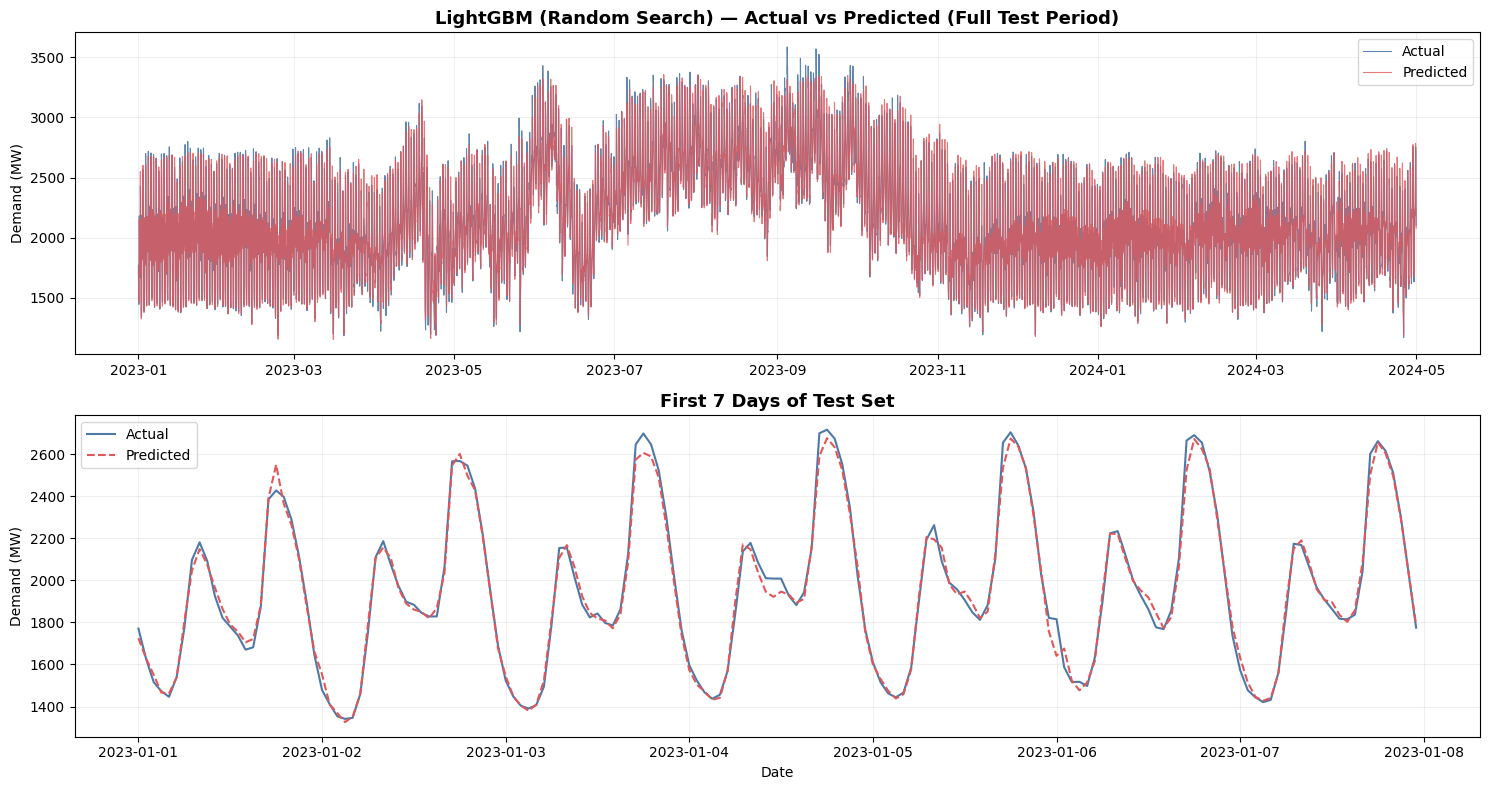

In [ ]:
import matplotlib.pyplot as plt

plot_df = test.iloc[:168].copy()
plot_pred_rs = y_pred_rs[:168]

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(test['datetime'], y_test.values,
             color='#4e79a7', linewidth=0.8, label='Actual', alpha=0.9)
axes[0].plot(test['datetime'], y_pred_rs,
             color='#e15759', linewidth=0.8, label='Predicted', alpha=0.8)
axes[0].set_title('LightGBM (Random Search) — Actual vs Predicted (Full Test Period)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Demand (MW)')
axes[0].legend()
axes[0].grid(alpha=0.2)

axes[1].plot(plot_df['datetime'], plot_df[TARGET].values,
             color='#4e79a7', linewidth=1.5, label='Actual')
axes[1].plot(plot_df['datetime'], plot_pred_rs,
             color='#e15759', linewidth=1.5, label='Predicted', linestyle='--')
axes[1].set_title('First 7 Days of Test Set', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Demand (MW)')
axes[1].set_xlabel('Date')
axes[1].legend()
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.savefig('lgbm_predictions_randomsearch.png', dpi=150)
plt.show()

In [ ]:
import pandas as pd

comparison_baseline_vs_rs = pd.DataFrame({
    'Metric': ['MAE (MW)', 'RMSE (MW)', 'MAPE (%)', 'R²'],
    'Original (hand-picked)': [41.48, 58.07, 1.91, 0.9827],
    'Random Search': [mae_rs, rmse_rs, mape_rs, r2_rs]
})
comparison_baseline_vs_rs['Improvement'] = comparison_baseline_vs_rs['Original (hand-picked)'] - comparison_baseline_vs_rs['Random Search']

print(comparison_baseline_vs_rs.to_string(index=False))

   Metric  Original (hand-picked)  Random Search  Improvement
 MAE (MW)                 41.4800      40.967568     0.512432
RMSE (MW)                 58.0700      57.674303     0.395697
 MAPE (%)                  1.9100       1.888936     0.021064
       R²                  0.9827       0.982920    -0.000220
